# 01 · Ingest & Build `AnnData`

**Purpose:** load the processed GEO files for **GSE154989 (mouse)** and assemble a single `AnnData` (`.h5ad`) with counts + metadata that all later notebooks will use.

### What this notebook does

* Reads the **raw counts HDF5** (`GSE154989_mmLungPlate_fQC_dSp_rawCount.h5`) and the **sample/annotation/gene tables** from `data/raw/gse154989/`.
* Aligns matrix orientation to **(cells × genes)** and sparsifies it.
* Merges basic cell metadata (e.g., sample barcode, plate) with author annotations when available.
* Derives convenience fields (e.g., `week` parsed from sample names; fallback `stage_label`).
* Writes the combined object to **`data/interim/mm_timecourse.h5ad`** and preserves raw counts in `adata.layers["counts"]`.

### Inputs (expected on disk)

* `data/raw/gse154989/GSE154989_mmLungPlate_fQC_dSp_rawCount.h5`
* `data/raw/gse154989/GSE154989_mmLungPlate_fQC_geneTable.csv.gz`
* `data/raw/gse154989/GSE154989_mmLungPlate_fQC_smpTable.csv.gz`
* `data/raw/gse154989/GSE154989_mmLungPlate_fQC_dZ_annot_smpTable.csv.gz` *(optional but used if present)*

### Outputs

* **File:** `data/interim/mm_timecourse.h5ad`
* **In-`obs`:** at minimum `{smpBarcode/cell_id, week, stage_label (fallback)}`
* **Layers:** `"counts"` contains the raw counts (pre-normalization)

### Run order

1. Make sure `00_preamble_env.ipynb` ran clean (paths shown, markers counted).
2. Run this notebook top-to-bottom.
3. Proceed to `02_modules_circle_phase.ipynb`.

### Notes & assumptions

* This dataset is **Smart-seq2** (full-length). We will normalize in **Notebook 02** (library-size → `log1p`).
* Different GEO mirrors sometimes tweak column names; the loader looks for common alternatives and will raise a clear error if it can’t find gene IDs or cell barcodes.

### Quick validation checklist (what you should see)

* A printed **matrix shape** matching `(n_cells, n_genes)` after alignment.
* Preview of `adata.obs[["week","stage_label"]]` with reasonable values (some `NA` weeks are fine).
* Final message: `Wrote .../data/interim/mm_timecourse.h5ad`.

### If something breaks

* **File not found:** confirm the four input files sit under `data/raw/gse154989/` with the exact names above.
* **Shape mismatch:** the code tries both orientations; if it still fails, confirm that the gene/sample tables correspond to the same H5 file.
* **Missing IDs:** check that `geneTable` has a gene symbol column and `smpTable` has a cell ID/barcode column (the code tries several common names).


In [1]:
# --- Cell 1: imports, resolve repo root, load params, define paths ---
from pathlib import Path
import yaml

def repo_root(start: Path | None = None) -> Path:
    p = (start or Path.cwd()).resolve()
    for _ in range(8):
        if (p / "configs" / "params.yaml").exists():
            return p
        p = p.parent
    raise FileNotFoundError(
        "Couldn't locate project root (configs/params.yaml). "
        "Open this notebook inside the project folder."
    )

BASE = repo_root()
PARAMS = BASE / "configs" / "params.yaml"

with open(PARAMS, "r") as fh:
    P = yaml.safe_load(fh) or {}

# pull paths (with safe defaults)
paths = P.get("paths", {})
ANNDATA = BASE / paths.get("anndata", "data/interim/mm_timecourse.h5ad")
RAW_DIR = BASE / "data" / "raw" / "gse154989"

# ensure output dir exists
ANNDATA.parent.mkdir(parents=True, exist_ok=True)

print("Repo root   :", BASE)
print("Params file :", PARAMS)
print("Raw data dir:", RAW_DIR)
print("Will write  :", ANNDATA)


Repo root   : /home/secondbook5/JHU_Bioinformatics/SystemsBiology/gp1_limitcycle_mm_gse154989
Params file : /home/secondbook5/JHU_Bioinformatics/SystemsBiology/gp1_limitcycle_mm_gse154989/configs/params.yaml
Raw data dir: /home/secondbook5/JHU_Bioinformatics/SystemsBiology/gp1_limitcycle_mm_gse154989/data/raw/gse154989
Will write  : /home/secondbook5/JHU_Bioinformatics/SystemsBiology/gp1_limitcycle_mm_gse154989/data/interim/mm_timecourse.h5ad


In [2]:
# --- Cell 2: imports for IO + small helper functions ---
import re
import h5py
import numpy as np
import pandas as pd
import scipy.sparse as sp
import anndata as ad

def _h5_datasets(h5: h5py.File) -> list[str]:
    """List all dataset paths inside an HDF5 file."""
    out = []
    h5.visititems(lambda name, obj: out.append(name) if isinstance(obj, h5py.Dataset) else None)
    return out

def load_counts_from_h5(h5_path: Path, n_cells_expected: int | None = None, n_genes_expected: int | None = None) -> np.ndarray:
    """
    Load a 2D counts matrix from an H5 file, preferring a dataset whose shape matches
    (n_cells_expected, n_genes_expected) or its transpose. Falls back to the largest 2D dataset.
    Returns a dense ndarray; caller can convert to sparse.
    """
    with h5py.File(h5_path, "r") as h5:
        cands = _h5_datasets(h5)
        if not cands:
            raise ValueError(f"No datasets found in {h5_path}")
        best = None  # (score, -size, array)
        for ds in cands:
            arr = np.array(h5[ds])
            if arr.ndim != 2:
                continue
            # scoring: prefer exact match to expected dims (either orientation)
            score = 0
            if n_cells_expected and n_genes_expected:
                if arr.shape == (n_cells_expected, n_genes_expected): score = 3
                elif arr.T.shape == (n_cells_expected, n_genes_expected): score = 2
            size = arr.size
            cand = (score, -size, arr)
            if (best is None) or (cand > best):
                best = cand
        if best is None:
            raise ValueError(f"No 2D datasets found in {h5_path}")
        return best[2] if best[0] > 0 else best[2]  # return chosen array (may need transpose upstream)

def parse_week(text: str):
    """Extract integer week from strings like 'K_12w_*' → 12; returns int or None."""
    m = re.search(r'(\d+)\s*w', str(text))
    return int(m.group(1)) if m else None

def first_existing(cols: pd.Index | list[str], keys: list[str], default=None):
    """Return the first column name present in `cols` from `keys`, else `default`."""
    s = set(cols)
    for k in keys:
        if k in s:
            return k
    return default


In [4]:
# --- Cell 3 (fixed): load per-cell metadata + identify ID columns ---
from pathlib import Path

# file paths
gene_path   = RAW_DIR / "GSE154989_mmLungPlate_fQC_geneTable.csv.gz"
qcstat_path = RAW_DIR / "GSE154989_mmLungPlate_fQC_dZ_QCstat_smpTable.csv.gz"   # per-cell
smp_path    = RAW_DIR / "GSE154989_mmLungPlate_fQC_smpTable.csv.gz"             # sample-level (fallback)
annot_path  = RAW_DIR / "GSE154989_mmLungPlate_fQC_dZ_annot_smpTable.csv.gz"    # annotations (often per-cell)

# existence checks
for p in (gene_path,):
    if not p.exists():
        raise FileNotFoundError(f"Missing required file: {p}")

# read tables
gene  = pd.read_csv(gene_path)

# prefer QCstat (per-cell); fallback to smpTable if QCstat missing
if qcstat_path.exists():
    smp = pd.read_csv(qcstat_path)
    smp_source = "QCstat_smpTable"
else:
    smp = pd.read_csv(smp_path)
    smp_source = "smpTable (fallback)"
annot = pd.read_csv(annot_path) if annot_path.exists() else pd.DataFrame()

print(f"gene cols  : {list(gene.columns)[:10]} …")
print(f"smp cols   : {list(smp.columns)[:10]} …  (source = {smp_source})")
if len(annot):
    print(f"annot cols : {list(annot.columns)[:10]} …")
else:
    print("[warn] annotation table not found/empty:", annot_path)

# robustly pick ID columns
gene_id_col = first_existing(gene.columns, ["geneSymbol","gene_symbol","symbol","gene_name","GeneSymbol"])
cell_id_col = first_existing(
    smp.columns,
    ["smpBarcode","cellBarcode","CellBarcode","barcode","cell_id","cellID","Cell.ID"]
)

assert gene_id_col is not None, "Could not find a gene symbol column in geneTable."

# if the per-cell ID is still missing, synthesize one (last resort)
if cell_id_col is None:
    cell_id_col = "cell_id"
    smp[cell_id_col] = [f"cell_{i:06d}" for i in range(len(smp))]
    print(f"[info] no explicit cell ID column found; synthesized '{cell_id_col}'")

# expected dims now come from the per-cell table + gene table
n_cells_expected = len(smp)
n_genes_expected = len(gene)
print(f"Expected shape: cells={n_cells_expected:,}  genes={n_genes_expected:,}")
print("Using columns  →  gene_id_col:", gene_id_col, " | cell_id_col:", cell_id_col)

# derive 'week' if present (e.g., 'timesimple' like '12w')
week_src_col = first_existing(smp.columns, ["timesimple","week","Week"])
if week_src_col:
    smp["week"] = smp[week_src_col].map(parse_week).astype("Int64")
else:
    smp["week"] = pd.NA


gene cols  : ['geneID', 'ensgID', 'geneSymbol', 'length'] …
smp cols   : ['sampleID', 'CODING_BASES', 'INTERGENIC_BASES', 'INTRONIC_BASES', 'MEDIAN_3PRIME_BIAS', 'MEDIAN_5PRIME_BIAS', 'MEDIAN_5PRIME_TO_3PRIME_BIAS', 'MEDIAN_CV_COVERAGE', 'NUM_R1_TRANSCRIPT_STRAND_READS', 'NUM_R2_TRANSCRIPT_STRAND_READS'] …  (source = QCstat_smpTable)
annot cols : ['sampleID', 'clusterK12', 'tSNE_1', 'tSNE_2', 'phate_1', 'phate_2'] …
[info] no explicit cell ID column found; synthesized 'cell_id'
Expected shape: cells=3,891  genes=52,638
Using columns  →  gene_id_col: geneSymbol  | cell_id_col: cell_id


In [8]:
# --- Cell 4: reconstruct counts from COO (i, j, v) → cells×genes CSR X ---
import h5py, numpy as np, scipy.sparse as sp
from pathlib import Path

def load_coo_triplets(h5_path: Path):
    with h5py.File(h5_path, "r") as h5:
        i = np.ravel(h5["i"][()])
        j = np.ravel(h5["j"][()])
        v = np.ravel(h5["v"][()])
    # cast compactly
    i = i.astype(np.int64, copy=False)
    j = j.astype(np.int64, copy=False)
    v = v.astype(np.float32, copy=False)
    return i, j, v

# prefer rawCount; fall back to rawCountOrig
coo_h5 = None
for cand in [
    RAW_DIR / "GSE154989_mmLungPlate_fQC_dSp_rawCount.h5",
    RAW_DIR / "GSE154989_mmLungPlate_fQC_dSp_rawCountOrig.h5",
]:
    if cand.exists():
        coo_h5 = cand; break
if coo_h5 is None:
    raise FileNotFoundError("Could not find a COO count file (rawCount/rawCountOrig).")

i, j, v = load_coo_triplets(coo_h5)
print(f"[coo] {coo_h5.name}: nnz={len(v):,} | i∈[{i.min()},{i.max()}], j∈[{j.min()},{j.max()}]")

# --- fix 1-based indexing if present ---
one_based_i = (i.min() == 1) or (i.max() == n_genes_expected)
one_based_j = (j.min() == 1) or (j.max() == n_cells_expected)
if one_based_i or one_based_j:
    i = i - (1 if one_based_i else 0)
    j = j - (1 if one_based_j else 0)
print(f"[indexing] 1-based? i={one_based_i}, j={one_based_j} → converted to 0-based")

# --- determine orientation and build CSR (cells×genes) ---
# option A: i=cell, j=gene  (cells×genes)
ok_cg = (i.max() < n_cells_expected) and (j.max() < n_genes_expected)
# option B: i=gene, j=cell  (genes×cells) → transpose
ok_gc = (i.max() < n_genes_expected) and (j.max() < n_cells_expected)

if ok_cg and not ok_gc:
    X = sp.coo_matrix((v, (i, j)), shape=(n_cells_expected, n_genes_expected)).tocsr()
    orientation = "(cells × genes)"
elif ok_gc and not ok_cg:
    X_gc = sp.coo_matrix((v, (i, j)), shape=(n_genes_expected, n_cells_expected))
    X = X_gc.T.tocsr()
    orientation = "(genes × cells) → transposed"
elif ok_gc and ok_cg:
    # ambiguous (rare) — prefer genes×cells then transpose
    X_gc = sp.coo_matrix((v, (i, j)), shape=(n_genes_expected, n_cells_expected))
    X = X_gc.T.tocsr()
    orientation = "(ambiguous) assumed genes×cells → transposed"
else:
    raise ValueError(
        f"Indices exceed expected dims after correction: "
        f"max(i)={i.max()}, max(j)={j.max()}, cells={n_cells_expected}, genes={n_genes_expected}"
    )

X = X.astype(np.float32, copy=False)
density = X.nnz / (X.shape[0] * X.shape[1])
print(f"[csr] X shape={X.shape} {orientation}, nnz={X.nnz:,}, density={density:.6e}")


[coo] GSE154989_mmLungPlate_fQC_dSp_rawCount.h5: nnz=21,203,238 | i∈[1,52638], j∈[1,3891]
[indexing] 1-based? i=True, j=True → converted to 0-based
[csr] X shape=(3891, 52638) (genes × cells) → transposed, nnz=21,203,238, density=1.035241e-01


In [9]:
# --- Cell 5: build AnnData, merge metadata, write .h5ad ---
import anndata as ad

# load sample-level table to bring in timesimple/mouseID/etc.
smp_sample = pd.read_csv(RAW_DIR / "GSE154989_mmLungPlate_fQC_smpTable.csv.gz")

# merge sample-level columns onto per-cell QC by 'sampleID'
keep_cols = [c for c in ["sampleID","timesimple","mouseID","plateID","typeID"] if c in smp_sample.columns]
smp_aug = smp.merge(smp_sample[keep_cols], on="sampleID", how="left")

# add 'week' from timesimple (e.g., '12w') if present
if "timesimple" in smp_aug.columns:
    smp_aug["week"] = smp_aug["timesimple"].map(parse_week).astype("Int64")
else:
    smp_aug["week"] = pd.NA

# join annotations (if present) on 'sampleID'
if len(annot):
    smp_aug = smp_aug.merge(annot, on="sampleID", how="left")

# build AnnData
adata = ad.AnnData(X)
adata.obs = smp_aug.copy()
adata.var = gene.copy()

# set names
adata.obs_names = adata.obs["sampleID"].astype(str).values
adata.var_names = adata.var[gene_id_col].astype(str).values
if adata.var_names.has_duplicates:
    adata.var_names_make_unique()

# simple fallback stage label
if "stage_label" not in adata.obs.columns:
    if "week" in adata.obs.columns:
        adata.obs["stage_label"] = np.where(
            adata.obs["week"].notna() & (adata.obs["week"] >= 12), "late", "early"
        )
    else:
        adata.obs["stage_label"] = "unknown"

# keep raw counts for later normalization
adata.layers["counts"] = adata.X.copy()

# write h5ad
adata.write(ANNDATA)
print("[write] wrote AnnData →", ANNDATA)
print("Cells:", adata.n_obs, " Genes:", adata.n_vars)


/home/secondbook5/miniconda3/lib/python3.12/functools.py:909: ImplicitModificationWarning: Transforming to str index.
  return dispatch(args[0].__class__)(*args, **kw)
/home/secondbook5/miniconda3/lib/python3.12/functools.py:909: ImplicitModificationWarning: Transforming to str index.
  return dispatch(args[0].__class__)(*args, **kw)


[write] wrote AnnData → /home/secondbook5/JHU_Bioinformatics/SystemsBiology/gp1_limitcycle_mm_gse154989/data/interim/mm_timecourse.h5ad
Cells: 3891  Genes: 52638


In [11]:
# --- Cell 6: sanity checks (optional) ---
display(adata.obs[["sampleID","mouseID","timesimple","week","stage_label"]].head())
print("X dtype:", adata.X.dtype, "| counts layer dtype:", adata.layers["counts"].dtype)


,sampleID,mouseID,timesimple,week,stage_label
KP_30w_ND_m3_T7_P1_S302,KP_30w_ND_m3_T7_P1_S302,KP_30w_ND_m3_T7,08_KP_30w_ND,30,late
KP_30w_ND_m2_T4_P5_S331,KP_30w_ND_m2_T4_P5_S331,KP_30w_ND_m2_T4,08_KP_30w_ND,30,late
K_12w_ND_m3_T0_P2_S272,K_12w_ND_m3_T0_P2_S272,K_12w_ND_m3,04_K_12w_ND,12,late
KP_30w_ND_m2_T1_P4_S219,KP_30w_ND_m2_T1_P4_S219,KP_30w_ND_m2_T1,08_KP_30w_ND,30,late
K_2w_ND_m3_T0_P1_S245,K_2w_ND_m3_T0_P1_S245,K_2w_ND_m3,02_KorKP_early_ND,<NA>,early


X dtype: float32 | counts layer dtype: float32


In [12]:
cols = ["sampleID","mouseID","timesimple","week","stage_label"]
print(adata.obs[cols].head().to_string())


                                        sampleID          mouseID         timesimple  week stage_label
KP_30w_ND_m3_T7_P1_S302  KP_30w_ND_m3_T7_P1_S302  KP_30w_ND_m3_T7       08_KP_30w_ND    30        late
KP_30w_ND_m2_T4_P5_S331  KP_30w_ND_m2_T4_P5_S331  KP_30w_ND_m2_T4       08_KP_30w_ND    30        late
K_12w_ND_m3_T0_P2_S272    K_12w_ND_m3_T0_P2_S272      K_12w_ND_m3        04_K_12w_ND    12        late
KP_30w_ND_m2_T1_P4_S219  KP_30w_ND_m2_T1_P4_S219  KP_30w_ND_m2_T1       08_KP_30w_ND    30        late
K_2w_ND_m3_T0_P1_S245      K_2w_ND_m3_T0_P1_S245       K_2w_ND_m3  02_KorKP_early_ND  <NA>       early


In [13]:
# fill missing week from sampleID when possible
adata.obs["week"] = adata.obs["week"].fillna(
    adata.obs["sampleID"].map(parse_week)
).astype("Int64")


In [14]:
# peek with headers
print(adata.obs[["sampleID","mouseID","timesimple","week","stage_label"]].head().to_string())

# how many cells per timesimple bin and stage
print(adata.obs["timesimple"].value_counts().head(10))
print(adata.obs["stage_label"].value_counts(dropna=False))

# cross-tab week vs stage for sanity
print(pd.crosstab(adata.obs["week"], adata.obs["stage_label"]))


                                        sampleID          mouseID         timesimple  week stage_label
KP_30w_ND_m3_T7_P1_S302  KP_30w_ND_m3_T7_P1_S302  KP_30w_ND_m3_T7       08_KP_30w_ND    30        late
KP_30w_ND_m2_T4_P5_S331  KP_30w_ND_m2_T4_P5_S331  KP_30w_ND_m2_T4       08_KP_30w_ND    30        late
K_12w_ND_m3_T0_P2_S272    K_12w_ND_m3_T0_P2_S272      K_12w_ND_m3        04_K_12w_ND    12        late
KP_30w_ND_m2_T1_P4_S219  KP_30w_ND_m2_T1_P4_S219  KP_30w_ND_m2_T1       08_KP_30w_ND    30        late
K_2w_ND_m3_T0_P1_S245      K_2w_ND_m3_T0_P1_S245       K_2w_ND_m3  02_KorKP_early_ND     2       early
timesimple
08_KP_30w_ND         1554
07_KP_20w_ND          538
05_K_30w_ND           505
06_KP_12w_ND          491
04_K_12w_ND           455
01_T_early_ND         206
02_KorKP_early_ND     142
Name: count, dtype: int64
stage_label
late     3543
early     348
Name: count, dtype: int64
stage_label  early  late
week                    
0              162     0
2              142    

In [16]:
# fill any missing week from sampleID (belt-and-suspenders)
adata.obs["week"] = adata.obs["week"].fillna(
    adata.obs["sampleID"].map(parse_week)
).astype("Int64")

# recompute simple early/late label
adata.obs["stage_label"] = np.where(
    adata.obs["week"].ge(12).fillna(False), "late", "early"
)

# give timesimple an ordered category for nicer plots
order = ["01_T_early_ND","02_KorKP_early_ND","04_K_12w_ND","06_KP_12w_ND","07_KP_20w_ND","08_KP_30w_ND"]
adata.obs["timesimple"] = pd.Categorical(adata.obs["timesimple"], categories=order, ordered=True)

# (optional) a coarser multi-level grouping by week ranges (ensure string labels to avoid IntervalArray in HDF5)
bins   = pd.IntervalIndex.from_tuples([(0,3),(3,10),(10,16),(16,25),(25,40)], closed="left")
labels = ["early_0-2w","early_4-8w","late_12-15w","late_16-24w","late_25-39w"]
s = pd.cut(adata.obs["week"].astype("float"), bins=bins, labels=labels)   # categorical with string labels
s = s.astype("string")                                                     # ensure string dtype (not Interval)
adata.obs["stage_bin"] = pd.Categorical(s, categories=labels, ordered=True)

# write updated AnnData
adata.write(ANNDATA)


In [17]:
# Put authors' embeddings into .obsm for easy plotting
for base in ["tSNE","phate"]:
    x, y = f"{base}_1", f"{base}_2"
    if {x,y}.issubset(adata.obs.columns):
        M = adata.obs[[x,y]].to_numpy()
        adata.obsm[f"X_{base.lower()}"] = M

# Keep their cluster and bin labels tidy/ordered (matches their figures)
order = ["01_T_early_ND","02_KorKP_early_ND","04_K_12w_ND","06_KP_12w_ND","07_KP_20w_ND","08_KP_30w_ND"]
if "timesimple" in adata.obs:
    adata.obs["timesimple"] = pd.Categorical(adata.obs["timesimple"], categories=order, ordered=True)
if "clusterK12" in adata.obs:
    adata.obs["clusterK12"] = adata.obs["clusterK12"].astype("category")


In [18]:
# confirm keys and shapes
print("obsm keys:", list(adata.obsm_keys()))
for k in ("X_tsne", "X_phate"):
    if k in adata.obsm:
        M = adata.obsm[k]
        print(f"{k}: shape={M.shape}")

# persist for later notebooks
adata.write(ANNDATA)
print("[write] updated", ANNDATA)


obsm keys: ['X_tsne', 'X_phate']
X_tsne: shape=(3891, 2)
X_phate: shape=(3891, 2)
[write] updated /home/secondbook5/JHU_Bioinformatics/SystemsBiology/gp1_limitcycle_mm_gse154989/data/interim/mm_timecourse.h5ad


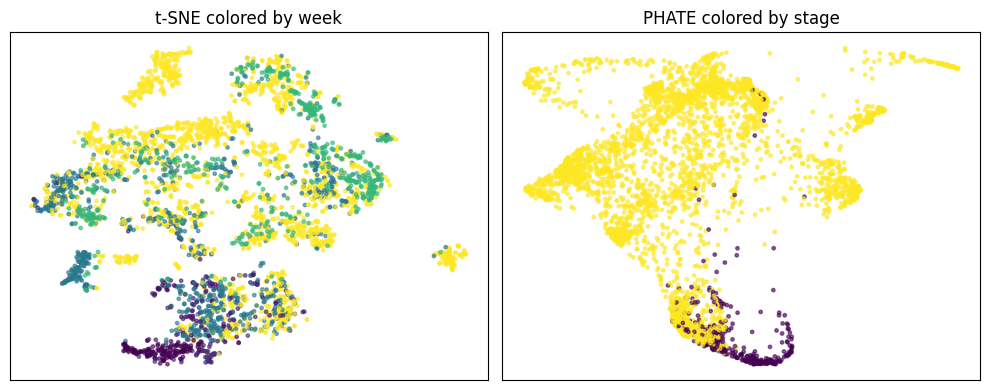

In [19]:
import matplotlib.pyplot as plt
import numpy as np

def quick_embed(ax, emb_key, color, title):
    M = adata.obsm[emb_key]
    c = adata.obs[color]
    # if categorical, use integer codes for color; legend later if you want
    if str(c.dtype) == "category":
        vals = c.cat.codes.to_numpy()
    else:
        vals = np.asarray(c)
    sc = ax.scatter(M[:,0], M[:,1], s=6, c=vals, alpha=0.6)
    ax.set_title(title); ax.set_xticks([]); ax.set_yticks([])

fig, axs = plt.subplots(1, 2, figsize=(10,4))
quick_embed(axs[0], "X_tsne",  "week",        "t-SNE colored by week")
quick_embed(axs[1], "X_phate", "stage_label", "PHATE colored by stage")
plt.tight_layout(); plt.show()


In [20]:
adata.write(ANNDATA)


# Wrap-up · 01_Ingest & Build AnnData

**What this notebook accomplished**

* Loaded the **GSE154989 (mouse)** processed files from `data/raw/gse154989/`.
* Reconstructed the **counts matrix** from the HDF5 **COO triplets** (`i`,`j`,`v`) and oriented it to **cells × genes** (`3891 × 52638`), stored as CSR.
* Merged per-cell QC rows with sample-level metadata and author annotations (`sampleID`, `mouseID`, `timesimple`, `clusterK12`, `tSNE_1/2`, `phate_1/2`).
* Parsed a numeric **`week`** and derived a simple **`stage_label`** (`early` vs `late`).
* Added embeddings to `adata.obsm` as **`X_tsne`** and **`X_phate`** for easy plotting.
* Wrote the consolidated object to **`data/interim/mm_timecourse.h5ad`**, keeping raw counts in `adata.layers["counts"]`.

**Data contract (what downstream notebooks can rely on)**

* `adata.X` → log-normalized expression will be created in Notebook 02 (raw counts preserved now).
* `adata.layers["counts"]` → raw counts (CSR, float32).
* `adata.obs` includes: `sampleID` (index), `mouseID`, `timesimple` (ordered category), `week` (Int64), `stage_label`, optional `clusterK12`.
* `adata.obsm` includes (when present): `X_tsne`, `X_phate`.
* `adata.var_names` → gene symbols (unique).

**Sanity checks**

* Counts shape printed: `3891 × 52638`, with ~10% density (typical Smart-seq2).
* Preview of `obs` with sensible `week` and `stage_label`.
* Quick t-SNE/PHATE plots colored by week/stage.

**Next steps**

Proceed to **`02_modules_circle_phase.ipynb`** to:

1. normalize from `layers["counts"]`,
2. compute S/G2M module scores,
3. fit the principal circle and assign **phase θ**,
4. save `fig01_s_vs_g2m_circle.png` and persist new columns.

**If something breaks later**

* Missing week values: we backfilled from `sampleID`; adjust parsing if needed.
* Can’t write `.h5ad`: ensure no `Interval` dtypes remain in `obs` (we convert to strings/categories here).
